In [1]:
!pip -q install xlrd openpyxl

import pandas as pd
import numpy as np
import math
import os
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for f in uploaded.keys():
    print(" -", f)

Saving OptionsPJM.xlsx to OptionsPJM.xlsx
Saving DataFutures.xlsx to DataFutures.xlsx
Saving GAS_FU_1.xlsx to GAS_FU_1.xlsx
Saving MHHNGSP.xlsx to MHHNGSP.xlsx
Uploaded files:
 - OptionsPJM.xlsx
 - DataFutures.xlsx
 - GAS_FU_1.xlsx
 - MHHNGSP.xlsx


In [24]:
from google.colab import files
uploaded = files.upload()

import os
print("Files now available:")
for f in os.listdir("."):
    print(f)

Saving 0._No_Standard_Table.csv to 0._No_Standard_Table.csv
Files now available:
.config
OptionsPJM.xlsx
DataFutures.xlsx
MHHNGSP.xlsx
GAS_FU_1.xlsx
0._No_Standard_Table.csv
sample_data


In [2]:
required_files = [
    "DataFutures.xlsx",
    "OptionsPJM.xlsx",
    "GAS_FU_1.xlxs",
    "MHHNGSP.xlsx",
]

for f in required_files:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

DataFutures.xlsx FOUND
OptionsPJM.xlsx FOUND
GAS_FU_1.xlxs MISSING
MHHNGSP.xlsx FOUND


In [3]:
import pandas as pd
import numpy as np
import os

gas_file = "GAS_FU_1.xlsx"

# Basic constants
HR = 6.60
VOM = 3.50
LEIDY_BASIS = -0.40

# Check workbook sheets
gas_xls = pd.ExcelFile(gas_file, engine="openpyxl")

print("Sheets in GAS_FU_1.xlsx:")
for sheet in gas_xls.sheet_names:
    print(" -", sheet)

Sheets in GAS_FU_1.xlsx:
 - NG Futures History
 - HH Spot Prices
 - Gas Vol & Options
 - Forward Curve Snapshot


In [26]:

# Gas forward curve from EIA STEO CSV

csv_files = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)

eia_csv = None
for f in csv_files:
    if "standard" in f.lower() or "table" in f.lower():
        eia_csv = f
        break

if eia_csv is None:
    eia_csv = csv_files[0]

print("Using EIA STEO CSV:", eia_csv)

# EIA CSV:
# rows 1-4 are metadata
# row 5 is actual header
# row 6 is actual data
eia_raw = pd.read_csv(eia_csv, skiprows=4)

display(eia_raw)
print(eia_raw.columns.tolist())

# Select Henry Hub row
hh_row = eia_raw[
    eia_raw["source key"].astype(str).str.strip().eq("NGHHUUS")
].iloc[0]

# Extract Jan 2026–Dec 2027
months = pd.date_range("2026-01-01", "2027-12-01", freq="MS")

records = []
for dt in months:
    col = dt.strftime("%b %Y")  # e.g., Jan 2026
    value = float(hh_row[col])
    records.append({
        "month": dt.strftime("%Y-%m"),
        "HH_raw_EIA": value
    })

gas_curve = pd.DataFrame(records)

# Base-case smoothing:
# Keep raw EIA value for documentation, but smooth Jan 2026 in valuation.
gas_curve["HH_proxy"] = gas_curve["HH_raw_EIA"]
gas_curve.loc[gas_curve["month"] == "2026-01", "HH_proxy"] = 4.00

# Calculate Leidy and fuel cost
gas_curve["Leidy_basis"] = LEIDY_BASIS
gas_curve["Leidy_fwd"] = gas_curve["HH_proxy"] + gas_curve["Leidy_basis"]
gas_curve["FuelCost_excl_VOM"] = HR * gas_curve["Leidy_fwd"]
gas_curve["FuelCost_MWh"] = gas_curve["FuelCost_excl_VOM"] + VOM

gas_curve = gas_curve[
    ["month", "HH_raw_EIA", "HH_proxy", "Leidy_basis", "Leidy_fwd",
     "FuelCost_excl_VOM", "FuelCost_MWh"]
].reset_index(drop=True)

display(gas_curve)

print("Rows:", len(gas_curve))
print("First month:", gas_curve["month"].iloc[0])
print("Last month:", gas_curve["month"].iloc[-1])
print("Jan 2026 raw EIA:", gas_curve.loc[gas_curve["month"]=="2026-01", "HH_raw_EIA"].iloc[0])
print("Jan 2026 smoothed base-case:", gas_curve.loc[gas_curve["month"]=="2026-01", "HH_proxy"].iloc[0])

CSV files found: ['0._No_Standard_Table.csv']
Using EIA STEO CSV: 0._No_Standard_Table.csv


,remove,Unnamed: 1,map,linechart,units,source key,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026,Jan 2027,Feb 2027,Mar 2027,Apr 2027,May 2027,Jun 2027,Jul 2027,Aug 2027,Sep 2027,Oct 2027,Nov 2027,Dec 2027
0,Natural Gas Henry Hub Spot Price ($/mmBtu),Natural Gas Henry Hub Spot Price ($/mmBtu),1,1,dollars per million btu,NGHHUUS,4.13,4.19,4.12,3.42,3.12,3.02,3.2,2.91,2.97,3.19,3.79,4.26,7.72,3.62,3.04,2.77,2.8,2.93,3.04,3.06,3.13,3.1,3.19,3.66,3.84,3.37,3.07,2.87,2.69,2.9,3.03,3.21,3.2,2.95,3.22,3.79
1,0. No Standard Table,0. No Standard Table,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


['remove', 'Unnamed: 1', 'map', 'linechart', 'units', 'source key', 'Jan 2025', 'Feb 2025', 'Mar 2025', 'Apr 2025', 'May 2025', 'Jun 2025', 'Jul 2025', 'Aug 2025', 'Sep 2025', 'Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026', 'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026', 'Jun 2026', 'Jul 2026', 'Aug 2026', 'Sep 2026', 'Oct 2026', 'Nov 2026', 'Dec 2026', 'Jan 2027', 'Feb 2027', 'Mar 2027', 'Apr 2027', 'May 2027', 'Jun 2027', 'Jul 2027', 'Aug 2027', 'Sep 2027', 'Oct 2027', 'Nov 2027', 'Dec 2027']


,month,HH_raw_EIA,HH_proxy,Leidy_basis,Leidy_fwd,FuelCost_excl_VOM,FuelCost_MWh
0,2026-01,7.72,4.00,-0.4,3.60,23.760,27.260
1,2026-02,3.62,3.62,-0.4,3.22,21.252,24.752
2,2026-03,3.04,3.04,-0.4,2.64,17.424,20.924
3,2026-04,2.77,2.77,-0.4,2.37,15.642,19.142
4,2026-05,2.80,2.80,-0.4,2.40,15.840,19.340
5,2026-06,2.93,2.93,-0.4,2.53,16.698,20.198
6,2026-07,3.04,3.04,-0.4,2.64,17.424,20.924
7,2026-08,3.06,3.06,-0.4,2.66,17.556,21.056
8,2026-09,3.13,3.13,-0.4,2.73,18.018,21.518
9,2026-10,3.10,3.10,-0.4,2.70,17.820,21.320


Rows: 24
First month: 2026-01
Last month: 2027-12
Jan 2026 raw EIA: 7.72
Jan 2026 smoothed base-case: 4.0


In [5]:
gas_curve = gas_curve_raw.copy()

# Keep only rows where delivery month is YYYY-MM
gas_curve = gas_curve[
    gas_curve["Delivery Month"].astype(str).str.match(r"^\d{4}-\d{2}$", na=False)
].copy()

# Rename columns
gas_curve = gas_curve.rename(columns={
    "Delivery Month": "month",
    "HH STEO ($/MMBtu)": "HH_proxy",
    "Leidy Basis\n($/MMBtu)": "Leidy_basis",
    "Leidy Fwd\n($/MMBtu)": "Leidy_fwd",
    "Fuel Cost @ HR=6.6\n($/MWh)": "FuelCost_excl_VOM",
    "Source / Notes": "source_notes"
})

# Convert numeric columns
for col in ["HH_proxy", "Leidy_basis", "Leidy_fwd", "FuelCost_excl_VOM"]:
    gas_curve[col] = pd.to_numeric(gas_curve[col], errors="coerce")

# Report valuation fuel cost includes VOM
gas_curve["FuelCost_MWh"] = HR * gas_curve["Leidy_fwd"] + VOM

# Keep clean columns
gas_curve = gas_curve[
    ["month", "HH_proxy", "Leidy_basis", "Leidy_fwd", "FuelCost_excl_VOM", "FuelCost_MWh", "source_notes"]
].reset_index(drop=True)

display(gas_curve)
print("Number of gas valuation months:", len(gas_curve))

,month,HH_proxy,Leidy_basis,Leidy_fwd,FuelCost_excl_VOM,FuelCost_MWh,source_notes
0,2026-01,4.00,-0.4,3.60,23.760,27.260,Jan-26 HH replaced from $7.72 spike → $4.00 (p...
1,2026-02,3.62,-0.4,3.22,21.252,24.752,EIA STEO Jan-2025
2,2026-03,3.06,-0.4,2.66,17.556,21.056,EIA STEO Jan-2025
3,2026-04,2.93,-0.4,2.53,16.698,20.198,EIA STEO Jan-2025
4,2026-05,2.98,-0.4,2.58,17.028,20.528,EIA STEO Jan-2025
5,2026-06,3.11,-0.4,2.71,17.886,21.386,EIA STEO Jan-2025
6,2026-07,3.21,-0.4,2.81,18.546,22.046,EIA STEO Jan-2025
7,2026-08,3.24,-0.4,2.84,18.744,22.244,EIA STEO Jan-2025
8,2026-09,3.31,-0.4,2.91,19.206,22.706,EIA STEO Jan-2025
9,2026-10,3.28,-0.4,2.88,19.008,22.508,EIA STEO Jan-2025


Number of gas valuation months: 24


In [6]:
import pandas as pd
import numpy as np
import math

gas_file = "GAS_FU_1.xlsx"

HR = 6.60
VOM = 3.50
LEIDY_BASIS = -0.40

gas_xls = pd.ExcelFile(gas_file, engine="openpyxl")
print(gas_xls.sheet_names)

['NG Futures History', 'HH Spot Prices', 'Gas Vol & Options', 'Forward Curve Snapshot']


In [7]:
gas_raw = pd.read_excel(
    gas_file,
    sheet_name="Forward Curve Snapshot",
    header=3,
    engine="openpyxl"
)

gas_curve = gas_raw.copy()

gas_curve = gas_curve[
    gas_curve["Delivery Month"].astype(str).str.match(r"^\d{4}-\d{2}$", na=False)
].copy()

gas_curve = gas_curve.rename(columns={
    "Delivery Month": "month",
    "HH STEO ($/MMBtu)": "HH_proxy"
})

gas_curve["HH_proxy"] = pd.to_numeric(gas_curve["HH_proxy"], errors="coerce")


gas_curve["Leidy_basis"] = LEIDY_BASIS
gas_curve["Leidy_fwd"] = gas_curve["HH_proxy"] + gas_curve["Leidy_basis"]
gas_curve["FuelCost_excl_VOM"] = HR * gas_curve["Leidy_fwd"]
gas_curve["FuelCost_MWh"] = gas_curve["FuelCost_excl_VOM"] + VOM

gas_curve = gas_curve[
    ["month", "HH_proxy", "Leidy_basis", "Leidy_fwd", "FuelCost_excl_VOM", "FuelCost_MWh"]
].reset_index(drop=True)

display(gas_curve)

,month,HH_proxy,Leidy_basis,Leidy_fwd,FuelCost_excl_VOM,FuelCost_MWh
0,2026-01,4.00,-0.4,3.60,23.760,27.260
1,2026-02,3.62,-0.4,3.22,21.252,24.752
2,2026-03,3.06,-0.4,2.66,17.556,21.056
3,2026-04,2.93,-0.4,2.53,16.698,20.198
4,2026-05,2.98,-0.4,2.58,17.028,20.528
5,2026-06,3.11,-0.4,2.71,17.886,21.386
6,2026-07,3.21,-0.4,2.81,18.546,22.046
7,2026-08,3.24,-0.4,2.84,18.744,22.244
8,2026-09,3.31,-0.4,2.91,19.206,22.706
9,2026-10,3.28,-0.4,2.88,19.008,22.508


In [8]:
hh_raw = pd.read_excel(
    gas_file,
    sheet_name="HH Spot Prices",
    header=4,
    engine="openpyxl"
)

hh = hh_raw.copy()
hh = hh.rename(columns={
    "Month": "month",
    "HH Monthly Avg\n($/MMBtu)": "HH_monthly_avg"
})

hh = hh[
    hh["month"].astype(str).str.match(r"^\d{4}-\d{2}$", na=False)
].copy()

hh["HH_monthly_avg"] = pd.to_numeric(hh["HH_monthly_avg"], errors="coerce")
hh = hh.dropna(subset=["HH_monthly_avg"]).reset_index(drop=True)

# Calculate log returns
hh["log_return"] = np.log(hh["HH_monthly_avg"] / hh["HH_monthly_avg"].shift(1))

display(hh.tail(10))

,month,HH_monthly_avg,MoM Log Return,12-Mo Realized Vol\n(annualised),Notes,log_return
343,2025-08,2.913,-0.09428,0.576442,NaN,-0.094280
344,2025-09,2.974,0.020724,0.572781,NaN,0.020724
345,2025-10,3.186,0.068858,0.568991,NaN,0.068858
346,2025-11,3.794,0.174655,0.474508,NaN,0.174655
347,2025-12,4.264,0.116787,0.356318,NaN,0.116787
348,2026-01,7.718,0.593348,0.71312,Extended cold winter demand,0.593348
349,2026-02,3.622,-0.756529,1.110829,NaN,-0.756529
350,2026-03,3.044,-0.173854,1.108738,NaN,-0.173854
351,2026-04,2.768,-0.095047,1.108922,NaN,-0.095047
352,2026-05,2.650,-0.043565,1.109275,NaN,-0.043565


In [9]:
gas_vol_window = hh[
    (hh["month"] >= "2024-01") &
    (hh["month"] <= "2025-12")
].copy()

returns = gas_vol_window["log_return"].dropna()

sigma_g_sample = returns.std(ddof=1) * math.sqrt(12)
sigma_g_population = returns.std(ddof=0) * math.sqrt(12)

print("Number of monthly prices:", len(gas_vol_window))
print("Number of log returns:", len(returns))
print("Gas vol, sample std annualized:", sigma_g_sample)
print("Gas vol, population std annualized:", sigma_g_population)

Number of monthly prices: 24
Number of log returns: 24
Gas vol, sample std annualized: 0.7020663824478882
Gas vol, population std annualized: 0.6872843820476743


In [10]:
import os
import math
import json
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import brentq

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

def find_file(keyword, extensions=(".xlsx", ".xls")):
    matches = [
        f for f in os.listdir(".")
        if keyword.lower() in f.lower() and f.lower().endswith(extensions)
    ]
    if not matches:
        raise FileNotFoundError(f"No file found containing '{keyword}'")
    return matches[0]

power_futures_file = find_file("DataFutures", extensions=(".xlsx",))
power_options_file = find_file("OptionsPJM", extensions=(".xlsx",))
gas_file = find_file("GAS_FU", extensions=(".xlsx",))
hh_file = find_file("MHHNGSP", extensions=(".xlsx",))

print("Using files:")
print("Power futures:", power_futures_file)
print("Power options:", power_options_file)
print("Gas workbook:", gas_file)
print("HH history:", hh_file)

Using files:
Power futures: DataFutures.xlsx
Power options: OptionsPJM.xlsx
Gas workbook: GAS_FU_1.xlsx
HH history: MHHNGSP.xlsx


In [11]:
AS_OF = pd.Timestamp("2025-01-02")

HR = 6.60                 # MMBtu/MWh
VOM = 3.50                # $/MWh
CAP_MW = 829              # MW
PEAK_HRS_MONTH = 320      # benchmark only; final model uses calculated monthly PeakHours
RF = 0.045                # risk-free rate
LEIDY_BASIS = -0.40       # $/MMBtu

START_MONTH = "2026-01"
END_MONTH = "2027-12"

In [12]:
gas_raw = pd.read_excel(
    gas_file,
    sheet_name="Forward Curve Snapshot",
    header=3,
    engine="openpyxl"
)

gas_curve = gas_raw.copy()

gas_curve = gas_curve[
    gas_curve["Delivery Month"].astype(str).str.match(r"^\d{4}-\d{2}$", na=False)
].copy()

gas_curve = gas_curve.rename(columns={
    "Delivery Month": "month",
    "HH STEO ($/MMBtu)": "HH_proxy"
})

gas_curve["HH_proxy"] = pd.to_numeric(gas_curve["HH_proxy"], errors="coerce")

# Calculated fields
gas_curve["Leidy_basis"] = LEIDY_BASIS
gas_curve["Leidy_fwd"] = gas_curve["HH_proxy"] + gas_curve["Leidy_basis"]
gas_curve["FuelCost_excl_VOM"] = HR * gas_curve["Leidy_fwd"]
gas_curve["FuelCost_MWh"] = gas_curve["FuelCost_excl_VOM"] + VOM

gas_curve = gas_curve[
    ["month", "HH_proxy", "Leidy_basis", "Leidy_fwd", "FuelCost_excl_VOM", "FuelCost_MWh"]
].reset_index(drop=True)

display(gas_curve)

print("Gas months:", gas_curve["month"].min(), "to", gas_curve["month"].max())
print("Rows:", len(gas_curve))

,month,HH_proxy,Leidy_basis,Leidy_fwd,FuelCost_excl_VOM,FuelCost_MWh
0,2026-01,4.00,-0.4,3.60,23.760,27.260
1,2026-02,3.62,-0.4,3.22,21.252,24.752
2,2026-03,3.06,-0.4,2.66,17.556,21.056
3,2026-04,2.93,-0.4,2.53,16.698,20.198
4,2026-05,2.98,-0.4,2.58,17.028,20.528
5,2026-06,3.11,-0.4,2.71,17.886,21.386
6,2026-07,3.21,-0.4,2.81,18.546,22.046
7,2026-08,3.24,-0.4,2.84,18.744,22.244
8,2026-09,3.31,-0.4,2.91,19.206,22.706
9,2026-10,3.28,-0.4,2.88,19.008,22.508


Gas months: 2026-01 to 2027-12
Rows: 24


In [13]:
hh = pd.read_excel(
    hh_file,
    sheet_name="Monthly",
    engine="openpyxl"
)

hh = hh.rename(columns={
    "observation_date": "date",
    "MHHNGSP": "HH_monthly"
})

hh["date"] = pd.to_datetime(hh["date"])
hh["month"] = hh["date"].dt.strftime("%Y-%m")
hh["HH_monthly"] = pd.to_numeric(hh["HH_monthly"], errors="coerce")

hh_window = hh[
    (hh["month"] >= "2024-01") &
    (hh["month"] <= "2025-12")
].copy()

hh_window["log_return"] = np.log(
    hh_window["HH_monthly"] / hh_window["HH_monthly"].shift(1)
)

gas_returns = hh_window["log_return"].dropna()

SIGMA_G = gas_returns.std(ddof=1) * math.sqrt(12)

print("Henry Hub monthly window:")
display(hh_window)

print("Number of monthly prices:", len(hh_window))
print("Number of log returns:", len(gas_returns))
print("Calculated annualized gas volatility SIGMA_G:", SIGMA_G)
print("Calculated annualized gas volatility (%):", SIGMA_G * 100)

Henry Hub monthly window:


,date,HH_monthly,month,log_return
324,2024-01-01,3.18,2024-01,NaN
325,2024-02-01,1.72,2024-02,-0.614557
326,2024-03-01,1.49,2024-03,-0.143548
327,2024-04-01,1.60,2024-04,0.071228
328,2024-05-01,2.12,2024-05,0.281412
329,2024-06-01,2.54,2024-06,0.180748
330,2024-07-01,2.07,2024-07,-0.204615
331,2024-08-01,1.99,2024-08,-0.039414
332,2024-09-01,2.28,2024-09,0.136041
333,2024-10-01,2.20,2024-10,-0.035718


Number of monthly prices: 24
Number of log returns: 23
Calculated annualized gas volatility SIGMA_G: 0.7025704439129515
Calculated annualized gas volatility (%): 70.25704439129515


In [14]:
def parse_contract_header(col):
    if isinstance(col, pd.Timestamp):
        return col.normalize()
    if hasattr(col, "year") and hasattr(col, "month") and hasattr(col, "day"):
        return pd.Timestamp(col).normalize()
    if isinstance(col, (int, float, np.integer, np.floating)):
        try:
            return pd.to_datetime(col, unit="D", origin="1899-12-30").normalize()
        except Exception:
            return col
    try:
        return pd.to_datetime(str(col), errors="raise").normalize()
    except Exception:
        return col

def expiration_to_delivery_month(expiration_date):
    exp = pd.Timestamp(expiration_date)
    delivery_start = exp.replace(day=1) - pd.DateOffset(months=1)
    return delivery_start.strftime("%Y-%m")

pwr_raw = pd.read_excel(power_futures_file, sheet_name=0, engine="openpyxl")

# First column is trade/settlement date
settle_col = pwr_raw.columns[0]
pwr = pwr_raw.rename(columns={settle_col: "SettlementDate"}).copy()
pwr["SettlementDate"] = pd.to_datetime(pwr["SettlementDate"], errors="coerce")
pwr = pwr.dropna(subset=["SettlementDate"]).copy()

# Parse contract expiration headers
new_cols = ["SettlementDate"] + [parse_contract_header(c) for c in pwr.columns[1:]]
pwr.columns = new_cols

contract_cols = [c for c in pwr.columns if c != "SettlementDate" and isinstance(c, pd.Timestamp)]
contract_cols = sorted(contract_cols)

# Convert all prices to numeric
for c in contract_cols:
    pwr[c] = pd.to_numeric(pwr[c].replace("NULL", np.nan), errors="coerce")

print("Power futures shape:", pwr.shape)
print("Settlement date range:", pwr["SettlementDate"].min(), "to", pwr["SettlementDate"].max())
print("Number of contract columns:", len(contract_cols))
print("First contract expiration:", min(contract_cols))
print("Last contract expiration:", max(contract_cols))

Power futures shape: (596, 158)
Settlement date range: 2024-01-02 00:00:00 to 2026-04-23 00:00:00
Number of contract columns: 157
First contract expiration: 2024-01-03 00:00:00
Last contract expiration: 2037-01-05 00:00:00


In [15]:
# Build mapping: expiration date -> delivery month
contract_map = pd.DataFrame({
    "contract_expiration": contract_cols
})
contract_map["delivery_month"] = contract_map["contract_expiration"].apply(expiration_to_delivery_month)

# Use latest available settlement on or before AS_OF
pwr_before = pwr[pwr["SettlementDate"] <= AS_OF].copy()

if pwr_before.empty:
    raise ValueError("No power futures data available on or before AS_OF date.")

# For each delivery month, use the latest non-null quote on or before AS_OF
power_rows = []

for _, row in contract_map.iterrows():
    exp_col = row["contract_expiration"]
    dm = row["delivery_month"]

    if dm < START_MONTH or dm > END_MONTH:
        continue

    temp = pwr_before[["SettlementDate", exp_col]].dropna().copy()
    if temp.empty:
        continue

    latest_row = temp.sort_values("SettlementDate").iloc[-1]

    power_rows.append({
        "month": dm,
        "contract_expiration": exp_col,
        "power_quote_date": latest_row["SettlementDate"],
        "F_elec_MWh": float(latest_row[exp_col])
    })

power_curve = pd.DataFrame(power_rows).sort_values("month").reset_index(drop=True)

display(power_curve)

print("Power valuation months:", len(power_curve))
print("First month:", power_curve["month"].min())
print("Last month:", power_curve["month"].max())

,month,contract_expiration,power_quote_date,F_elec_MWh
0,2026-01,2026-02-03,2025-01-02,76.75
1,2026-02,2026-03-03,2025-01-02,67.30
2,2026-03,2026-04-02,2025-01-02,52.40
3,2026-04,2026-05-04,2025-01-02,47.95
4,2026-05,2026-06-02,2025-01-02,50.30
5,2026-06,2026-07-02,2025-01-02,53.55
6,2026-07,2026-08-04,2025-01-02,77.90
7,2026-08,2026-09-02,2025-01-02,70.40
8,2026-09,2026-10-02,2025-01-02,54.60
9,2026-10,2026-11-03,2025-01-02,51.90


Power valuation months: 24
First month: 2026-01
Last month: 2027-12


In [16]:
display(power_curve.head(12))
display(power_curve.tail(12))

,month,contract_expiration,power_quote_date,F_elec_MWh
0,2026-01,2026-02-03,2025-01-02,76.75
1,2026-02,2026-03-03,2025-01-02,67.30
2,2026-03,2026-04-02,2025-01-02,52.40
3,2026-04,2026-05-04,2025-01-02,47.95
4,2026-05,2026-06-02,2025-01-02,50.30
5,2026-06,2026-07-02,2025-01-02,53.55
6,2026-07,2026-08-04,2025-01-02,77.90
7,2026-08,2026-09-02,2025-01-02,70.40
8,2026-09,2026-10-02,2025-01-02,54.60
9,2026-10,2026-11-03,2025-01-02,51.90


,month,contract_expiration,power_quote_date,F_elec_MWh
12,2027-01,2027-02-02,2025-01-02,82.30
13,2027-02,2027-03-02,2025-01-02,75.50
14,2027-03,2027-04-02,2025-01-02,56.60
15,2027-04,2027-05-04,2025-01-02,51.55
16,2027-05,2027-06-02,2025-01-02,54.55
17,2027-06,2027-07-02,2025-01-02,56.60
18,2027-07,2027-08-03,2025-01-02,81.40
19,2027-08,2027-09-02,2025-01-02,74.30
20,2027-09,2027-10-04,2025-01-02,57.80
21,2027-10,2027-11-02,2025-01-02,54.15


In [17]:
opts_xls = pd.ExcelFile(power_options_file, engine="openpyxl")

print("Options workbook sheets:", opts_xls.sheet_names)

# Usually the sheet is named "Options " with trailing space
opts_sheet = None
for s in opts_xls.sheet_names:
    if s.strip().lower() == "options":
        opts_sheet = s
        break

if opts_sheet is None:
    opts_sheet = opts_xls.sheet_names[0]

opts = pd.read_excel(power_options_file, sheet_name=opts_sheet, engine="openpyxl")

display(opts.head())
print(opts.columns.tolist())

Options workbook sheets: ['Options ']


,ProductCode,ProductType,ContractDate,ExpirationDate,SettlementDate,OptionType,Strike,Premium,UnderlyingPrice,DaysToExpiry
0,PMI,Peak Futures (1 MW),46023,46021,2025-01-02,P,76,19.51,76.75,362
1,PMI,Peak Futures (1 MW),46023,46021,2025-01-02,C,77,19.96,76.75,362
2,PMI,Peak Futures (1 MW),46054,46051,2025-01-02,P,67,17.71,67.30,392
3,PMI,Peak Futures (1 MW),46054,46051,2025-01-02,C,68,17.73,67.30,392
4,PMI,Peak Futures (1 MW),46082,46079,2025-01-02,P,52,8.75,52.40,420


['ProductCode', 'ProductType', 'ContractDate', 'ExpirationDate', 'SettlementDate', 'OptionType', 'Strike', 'Premium', 'UnderlyingPrice', 'DaysToExpiry']


In [18]:
def parse_excel_date(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, pd.Timestamp):
        return x.normalize()
    if hasattr(x, "year") and hasattr(x, "month") and hasattr(x, "day"):
        return pd.Timestamp(x).normalize()
    if isinstance(x, (int, float, np.integer, np.floating)):
        return pd.to_datetime(x, unit="D", origin="1899-12-30").normalize()
    return pd.to_datetime(x, errors="coerce")

for col in ["ContractDate", "ExpirationDate", "SettlementDate"]:
    opts[col] = opts[col].apply(parse_excel_date)

for col in ["Strike", "Premium", "UnderlyingPrice", "DaysToExpiry"]:
    opts[col] = pd.to_numeric(opts[col], errors="coerce")

opts["OptionType"] = opts["OptionType"].astype(str).str.upper().str.strip()
opts["T"] = opts["DaysToExpiry"] / 365.0
opts["abs_moneyness"] = abs(opts["Strike"] - opts["UnderlyingPrice"]) / opts["UnderlyingPrice"]

display(opts.head())

,ProductCode,ProductType,ContractDate,ExpirationDate,SettlementDate,OptionType,Strike,Premium,UnderlyingPrice,DaysToExpiry,T,abs_moneyness
0,PMI,Peak Futures (1 MW),2026-01-01,2025-12-30,2025-01-02,P,76,19.51,76.75,362,0.991781,0.009772
1,PMI,Peak Futures (1 MW),2026-01-01,2025-12-30,2025-01-02,C,77,19.96,76.75,362,0.991781,0.003257
2,PMI,Peak Futures (1 MW),2026-02-01,2026-01-29,2025-01-02,P,67,17.71,67.30,392,1.073973,0.004458
3,PMI,Peak Futures (1 MW),2026-02-01,2026-01-29,2025-01-02,C,68,17.73,67.30,392,1.073973,0.010401
4,PMI,Peak Futures (1 MW),2026-03-01,2026-02-26,2025-01-02,P,52,8.75,52.40,420,1.150685,0.007634


In [19]:
def black76_price(F, K, T, sigma, option_type, r=RF):
    if pd.isna(F) or pd.isna(K) or pd.isna(T) or pd.isna(sigma):
        return np.nan
    if F <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        intrinsic = max(F - K, 0.0) if option_type == "C" else max(K - F, 0.0)
        return math.exp(-r * max(T, 0)) * intrinsic

    d1 = (math.log(F / K) + 0.5 * sigma**2 * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    disc = math.exp(-r * T)

    if option_type == "C":
        return disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    elif option_type == "P":
        return disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    else:
        return np.nan

def implied_vol_black76(price, F, K, T, option_type, r=RF):
    if pd.isna(price) or pd.isna(F) or pd.isna(K) or pd.isna(T):
        return np.nan
    if price <= 0 or F <= 0 or K <= 0 or T <= 0:
        return np.nan

    def objective(sigma):
        return black76_price(F, K, T, sigma, option_type, r) - price

    try:
        low = 1e-6
        high = 5.0

        if objective(low) * objective(high) > 0:
            return np.nan

        return brentq(objective, low, high, maxiter=500)
    except Exception:
        return np.nan

opts["implied_vol"] = opts.apply(
    lambda r: implied_vol_black76(
        price=r["Premium"],
        F=r["UnderlyingPrice"],
        K=r["Strike"],
        T=r["T"],
        option_type=r["OptionType"],
        r=RF
    ),
    axis=1
)

display(opts[[
    "ContractDate", "OptionType", "Strike", "Premium",
    "UnderlyingPrice", "DaysToExpiry", "abs_moneyness", "implied_vol"
]].head(20))

print("Failed IV rows:", opts["implied_vol"].isna().sum())

,ContractDate,OptionType,Strike,Premium,UnderlyingPrice,DaysToExpiry,abs_moneyness,implied_vol
0,2026-01-01,P,76,19.51,76.75,362,0.009772,0.698432
1,2026-01-01,C,77,19.96,76.75,362,0.003257,0.701435
2,2026-02-01,P,67,17.71,67.30,392,0.004458,0.689275
3,2026-02-01,C,68,17.73,67.30,392,0.010401,0.692322
4,2026-03-01,P,52,8.75,52.40,420,0.007634,0.425061
5,2026-03-01,C,53,8.78,52.40,420,0.011450,0.426874
6,2026-04-01,P,47,7.46,47.95,452,0.019812,0.399645
7,2026-04-01,C,48,8.02,47.95,452,0.001043,0.402649
8,2026-05-01,P,50,8.41,50.30,482,0.005964,0.398128
9,2026-05-01,C,51,8.35,50.30,482,0.013917,0.400008


Failed IV rows: 0


In [20]:
# nearest ATM call and put for each contract month
atm_calls = (
    opts[opts["OptionType"] == "C"]
    .sort_values(["ContractDate", "abs_moneyness"])
    .groupby("ContractDate", as_index=False)
    .first()
)

atm_puts = (
    opts[opts["OptionType"] == "P"]
    .sort_values(["ContractDate", "abs_moneyness"])
    .groupby("ContractDate", as_index=False)
    .first()
)

power_iv_table = pd.merge(
    atm_calls[["ContractDate", "ExpirationDate", "UnderlyingPrice", "Strike", "Premium", "implied_vol", "abs_moneyness"]]
    .rename(columns={
        "Strike": "call_strike",
        "Premium": "call_premium",
        "implied_vol": "call_iv",
        "abs_moneyness": "call_abs_moneyness"
    }),
    atm_puts[["ContractDate", "Strike", "Premium", "implied_vol", "abs_moneyness"]]
    .rename(columns={
        "Strike": "put_strike",
        "Premium": "put_premium",
        "implied_vol": "put_iv",
        "abs_moneyness": "put_abs_moneyness"
    }),
    on="ContractDate",
    how="outer"
)

power_iv_table["month"] = pd.to_datetime(power_iv_table["ContractDate"]).dt.strftime("%Y-%m")
power_iv_table["atm_iv_avg"] = power_iv_table[["call_iv", "put_iv"]].mean(axis=1)

power_iv_table = power_iv_table.sort_values("month").reset_index(drop=True)

SIGMA_E = power_iv_table["atm_iv_avg"].mean()

display(power_iv_table)

print("Mean call IV:", power_iv_table["call_iv"].mean())
print("Mean put IV:", power_iv_table["put_iv"].mean())
print("Overall power IV SIGMA_E:", SIGMA_E)
print("Overall power IV (%):", SIGMA_E * 100)

,ContractDate,ExpirationDate,UnderlyingPrice,call_strike,call_premium,call_iv,call_abs_moneyness,put_strike,put_premium,put_iv,put_abs_moneyness,month,atm_iv_avg
0,2026-01-01,2025-12-30,76.75,77,19.96,0.701435,0.003257,76,19.51,0.698432,0.009772,2026-01,0.699934
1,2026-02-01,2026-01-29,67.30,68,17.73,0.692322,0.010401,67,17.71,0.689275,0.004458,2026-02,0.690798
2,2026-03-01,2026-02-26,52.40,53,8.78,0.426874,0.011450,52,8.75,0.425061,0.007634,2026-03,0.425967
3,2026-04-01,2026-03-30,47.95,48,8.02,0.402649,0.001043,47,7.46,0.399645,0.019812,2026-04,0.401147
4,2026-05-01,2026-04-29,50.30,51,8.35,0.400008,0.013917,50,8.41,0.398128,0.005964,2026-05,0.399068
5,2026-06-01,2026-05-28,53.55,54,9.49,0.410992,0.008403,53,9.29,0.408219,0.010271,2026-06,0.409606
6,2026-07-01,2026-06-29,77.90,78,16.67,0.477925,0.001284,77,16.12,0.475798,0.011553,2026-07,0.476861
7,2026-08-01,2026-07-30,70.40,71,16.28,0.511079,0.008523,70,16.20,0.509300,0.005682,2026-08,0.510189
8,2026-09-01,2026-08-28,54.60,55,10.01,0.395003,0.007326,54,9.76,0.392387,0.010989,2026-09,0.393695
9,2026-10-01,2026-09-29,51.90,52,9.66,0.388181,0.001927,51,9.13,0.385203,0.017341,2026-10,0.386692


Mean call IV: 0.4671858889027627
Mean put IV: 0.46479623969550526
Overall power IV SIGMA_E: 0.465991064299134
Overall power IV (%): 46.5991064299134


In [21]:
# Power monthly proxy:
# for each trading day, average all available futures quotes;
# then take the monthly average of that composite forward level.
pwr_level = pwr.copy()
pwr_level["power_forward_avg"] = pwr_level[contract_cols].mean(axis=1, skipna=True)
pwr_level["month"] = pwr_level["SettlementDate"].dt.strftime("%Y-%m")

power_monthly = (
    pwr_level.groupby("month", as_index=False)["power_forward_avg"]
    .mean()
)

# Gas monthly from MHHNGSP
gas_monthly = hh[["month", "HH_monthly"]].copy()

corr_df = pd.merge(
    power_monthly,
    gas_monthly,
    on="month",
    how="inner"
)

corr_df = corr_df[
    (corr_df["month"] >= "2024-01") &
    (corr_df["month"] <= "2025-12")
].copy()

corr_df["power_log_return"] = np.log(
    corr_df["power_forward_avg"] / corr_df["power_forward_avg"].shift(1)
)

corr_df["gas_log_return"] = np.log(
    corr_df["HH_monthly"] / corr_df["HH_monthly"].shift(1)
)

corr_returns = corr_df.dropna(subset=["power_log_return", "gas_log_return"]).copy()

RHO = corr_returns["power_log_return"].corr(corr_returns["gas_log_return"])

display(corr_df)
print("Number of paired return observations:", len(corr_returns))
print("Calculated power-gas correlation RHO:", RHO)

,month,power_forward_avg,HH_monthly,power_log_return,gas_log_return
0,2024-01,56.225489,3.18,NaN,NaN
1,2024-02,55.031937,1.72,-0.021457,-0.614557
2,2024-03,58.075327,1.49,0.053827,-0.143548
3,2024-04,66.379075,1.60,0.133641,0.071228
4,2024-05,70.651234,2.12,0.062374,0.281412
5,2024-06,68.330621,2.54,-0.033398,0.180748
6,2024-07,63.595489,2.07,-0.071815,-0.204615
7,2024-08,60.175792,1.99,-0.055272,-0.039414
8,2024-09,59.075937,2.28,-0.018446,0.136041
9,2024-10,58.696265,2.20,-0.006448,-0.035718


Number of paired return observations: 23
Calculated power-gas correlation RHO: 0.33449422215605323


In [31]:
# =========================
# Monthly peak-hour calculation
# 16 peak hours per weekday, excluding NERC holidays
# =========================

from datetime import date, timedelta

def observed_if_sunday(d):
    if d.weekday() == 6:  # Sunday
        return d + timedelta(days=1)
    return d

def nerc_holidays(year):
    holidays = set()

    # New Year's Day
    holidays.add(observed_if_sunday(date(year, 1, 1)))

    # Memorial Day: last Monday in May
    d = date(year, 5, 31)
    holidays.add(d - timedelta(days=(d.weekday() - 0) % 7))

    # Independence Day
    holidays.add(observed_if_sunday(date(year, 7, 4)))

    # Labor Day: first Monday in September
    d = date(year, 9, 1)
    holidays.add(d + timedelta(days=(0 - d.weekday()) % 7))

    # Thanksgiving: fourth Thursday in November
    d = date(year, 11, 1)
    first_thu = d + timedelta(days=(3 - d.weekday()) % 7)
    holidays.add(first_thu + timedelta(days=21))

    # Christmas
    holidays.add(observed_if_sunday(date(year, 12, 25)))

    return holidays

def monthly_peak_hours(month_str):
    start = pd.Timestamp(month_str + "-01")
    end = start + pd.offsets.MonthEnd(0)

    holidays = nerc_holidays(start.year)
    days = pd.date_range(start, end, freq="D")

    peak_days = [
        d for d in days
        if d.weekday() < 5 and d.date() not in holidays
    ]

    return len(peak_days) * 16

peak_hours_table = pd.DataFrame({
    "month": pd.period_range("2026-01", "2027-12", freq="M").astype(str)
})

peak_hours_table["PeakHours"] = peak_hours_table["month"].apply(monthly_peak_hours)

display(peak_hours_table)
print("Average monthly peak hours:", peak_hours_table["PeakHours"].mean())

,month,PeakHours
0,2026-01,336
1,2026-02,320
2,2026-03,352
3,2026-04,352
4,2026-05,320
5,2026-06,352
6,2026-07,368
7,2026-08,336
8,2026-09,336
9,2026-10,352


Average monthly peak hours: 341.3333333333333


In [32]:
def kirk_spread_call(F1, F2, sigma1, sigma2, rho, T, r=RF):
    """
    Kirk approximation for call on spread F1 - F2.
    F1 = power forward $/MWh
    F2 = HR * gas forward + VOM, in $/MWh
    """
    if F1 <= 0 or F2 <= 0 or T <= 0:
        return 0.0

    a = F2 / F1

    sigma_spread = math.sqrt(
        sigma1**2 +
        (a * sigma2)**2 -
        2 * rho * sigma1 * a * sigma2
    )

    sigma_spread = max(sigma_spread, 1e-8)

    d1 = (math.log(F1 / F2) + 0.5 * sigma_spread**2 * T) / (sigma_spread * math.sqrt(T))
    d2 = d1 - sigma_spread * math.sqrt(T)

    disc = math.exp(-r * T)

    C = disc * (F1 * norm.cdf(d1) - F2 * norm.cdf(d2))
    return max(C, 0.0)


# Merge power and gas curves
valuation = pd.merge(
    power_curve[["month", "F_elec_MWh", "power_quote_date", "contract_expiration"]],
    gas_curve[["month", "HH_proxy", "Leidy_basis", "Leidy_fwd", "FuelCost_MWh"]],
    on="month",
    how="inner"
)

valuation = pd.merge(
    valuation,
    peak_hours_table,
    on="month",
    how="left"
)

# Add option expiration dates from OptionsPJM / power IV table
expiration_lookup = power_iv_table[["month", "ExpirationDate"]].copy()

valuation = pd.merge(
    valuation,
    expiration_lookup,
    on="month",
    how="left"
)

# Use option expiration date for time to expiry
valuation["T_years"] = (
    pd.to_datetime(valuation["ExpirationDate"]) - AS_OF
).dt.days / 365.0

# Calculate spark spread
valuation["SparkFwd_MWh"] = valuation["F_elec_MWh"] - valuation["FuelCost_MWh"]

# Calculate Kirk option price
valuation["KirksPrice_MWh"] = valuation.apply(
    lambda r: kirk_spread_call(
        F1=r["F_elec_MWh"],
        F2=r["FuelCost_MWh"],
        sigma1=SIGMA_E,
        sigma2=SIGMA_G,
        rho=RHO,
        T=r["T_years"],
        r=RF
    ),
    axis=1
)

# Convert $/MWh option price into monthly $M value
valuation["EnergyValue_M"] = (
    valuation["KirksPrice_MWh"] * CAP_MW * valuation["PeakHours"] / 1e6
)

valuation_display = valuation[[
    "month",
    "ExpirationDate",
    "T_years",
    "PeakHours",
    "F_elec_MWh",
    "HH_proxy",
    "Leidy_fwd",
    "FuelCost_MWh",
    "SparkFwd_MWh",
    "KirksPrice_MWh",
    "EnergyValue_M"
]].copy()

for col in [
    "T_years",
    "F_elec_MWh",
    "HH_proxy",
    "Leidy_fwd",
    "FuelCost_MWh",
    "SparkFwd_MWh",
    "KirksPrice_MWh",
    "EnergyValue_M"
]:
    valuation_display[col] = valuation_display[col].round(3)

display(valuation_display)

,month,ExpirationDate,T_years,PeakHours,F_elec_MWh,HH_proxy,Leidy_fwd,FuelCost_MWh,SparkFwd_MWh,KirksPrice_MWh,EnergyValue_M
0,2026-01,2025-12-30,0.992,336,76.75,4.00,3.60,27.260,49.490,47.397,13.202
1,2026-02,2026-01-29,1.074,320,67.30,3.62,3.22,24.752,42.548,40.643,10.782
2,2026-03,2026-02-26,1.151,352,52.40,3.04,2.64,20.924,31.476,30.065,8.773
3,2026-04,2026-03-30,1.238,352,47.95,2.77,2.37,19.142,28.808,27.445,8.009
4,2026-05,2026-04-29,1.321,320,50.30,2.80,2.40,19.340,30.960,29.370,7.791
5,2026-06,2026-05-28,1.400,352,53.55,2.93,2.53,20.198,33.352,31.533,9.202
6,2026-07,2026-06-29,1.488,368,77.90,3.04,2.64,20.924,56.976,53.333,16.270
7,2026-08,2026-07-30,1.573,336,70.40,3.06,2.66,21.056,49.344,46.074,12.834
8,2026-09,2026-08-28,1.652,336,54.60,3.13,2.73,21.518,33.082,31.141,8.674
9,2026-10,2026-09-29,1.740,352,51.90,3.10,2.70,21.320,30.580,28.842,8.416


In [33]:
y2026 = valuation.loc[valuation["month"].str.startswith("2026"), "EnergyValue_M"].sum()
y2027 = valuation.loc[valuation["month"].str.startswith("2027"), "EnergyValue_M"].sum()
strip_total = valuation["EnergyValue_M"].sum()

cap_revenue_M = 329.17 * 365 * CAP_MW / 1e6

print("========== CALCULATED INPUTS ==========")
print(f"Power IV SIGMA_E: {SIGMA_E:.4f} = {SIGMA_E*100:.2f}%")
print(f"Gas vol SIGMA_G: {SIGMA_G:.4f} = {SIGMA_G*100:.2f}%")
print(f"Correlation RHO: {RHO:.4f}")

print("\n========== STRIP VALUE ==========")
print(f"2026 energy strip: ${y2026:.2f}M")
print(f"2027 energy strip: ${y2027:.2f}M")
print(f"24-month total strip: ${strip_total:.2f}M")

print("\n========== CAPACITY CONTEXT ==========")
print(f"Capacity revenue upper-bound estimate: ${cap_revenue_M:.2f}M/year")

========== CALCULATED INPUTS ==========
Power IV SIGMA_E: 0.4660 = 46.60%
Gas vol SIGMA_G: 0.7026 = 70.26%
Correlation RHO: 0.3345

========== STRIP VALUE ==========
2026 energy strip: $121.13M
2027 energy strip: $128.82M
24-month total strip: $249.95M

========== CAPACITY CONTEXT ==========
Capacity revenue upper-bound estimate: $99.60M/year


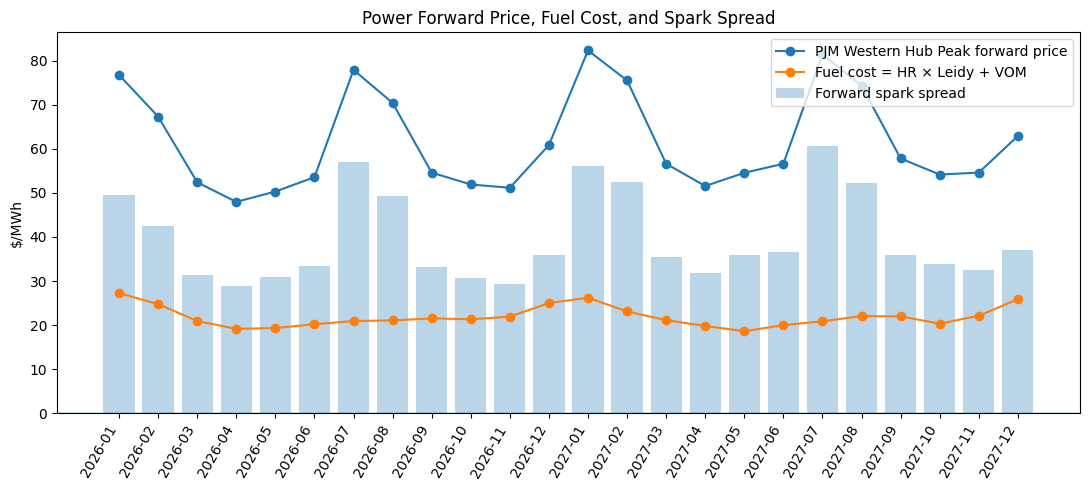

Saved: report_figures/fig1_power_fuel_spark_curve.png


In [40]:
plt.figure(figsize=(11, 5))

plt.plot(x, valuation["F_elec_MWh"], marker="o", label="PJM Western Hub Peak forward price")
plt.plot(x, valuation["FuelCost_MWh"], marker="o", label="Fuel cost = HR × Leidy + VOM")
plt.bar(x, valuation["SparkFwd_MWh"], alpha=0.3, label="Forward spark spread")

plt.axhline(0, linewidth=1)
plt.xticks(x, months, rotation=60, ha="right")
plt.ylabel("$/MWh")
plt.title("Power Forward Price, Fuel Cost, and Spark Spread")
plt.legend()

save_fig("fig1_power_fuel_spark_curve.png")

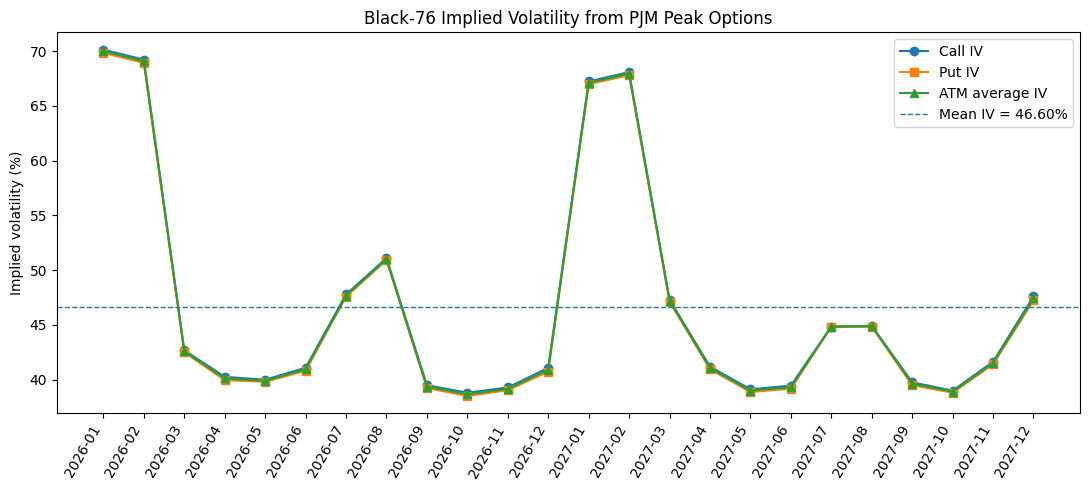

Saved: report_figures/fig2_black76_power_implied_volatility.png


In [41]:
iv = power_iv_table.sort_values("month").copy()
iv_x = np.arange(len(iv))
iv_months = iv["month"].tolist()

plt.figure(figsize=(11, 5))

plt.plot(iv_x, iv["call_iv"] * 100, marker="o", label="Call IV")
plt.plot(iv_x, iv["put_iv"] * 100, marker="s", label="Put IV")
plt.plot(iv_x, iv["atm_iv_avg"] * 100, marker="^", label="ATM average IV")

plt.axhline(SIGMA_E * 100, linestyle="--", linewidth=1, label=f"Mean IV = {SIGMA_E*100:.2f}%")
plt.xticks(iv_x, iv_months, rotation=60, ha="right")
plt.ylabel("Implied volatility (%)")
plt.title("Black-76 Implied Volatility from PJM Peak Options")
plt.legend()

save_fig("fig2_black76_power_implied_volatility.png")

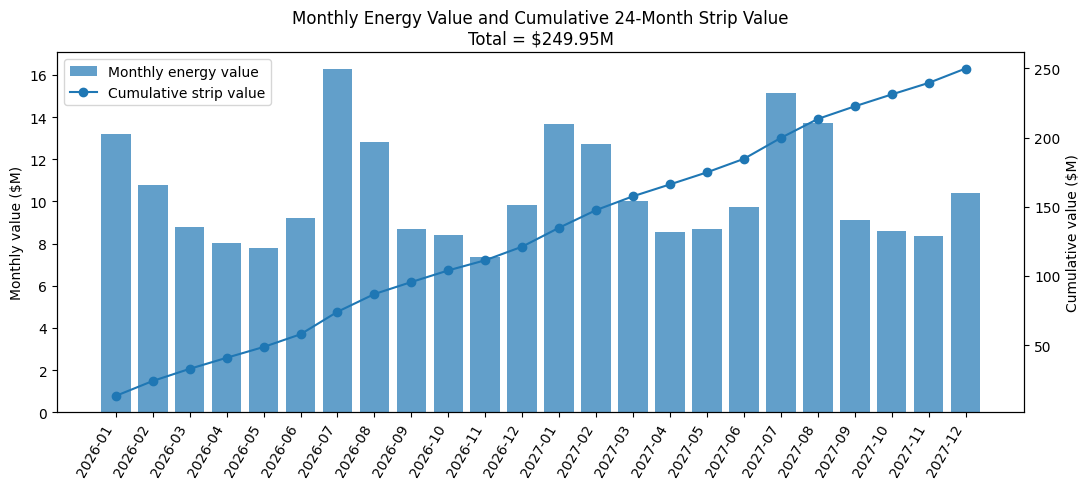

Saved: report_figures/fig3_monthly_energy_and_cumulative_strip.png


In [42]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(x, valuation["EnergyValue_M"], alpha=0.7, label="Monthly energy value")
ax1.set_ylabel("Monthly value ($M)")
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=60, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, valuation["EnergyValue_M"].cumsum(), marker="o", label="Cumulative strip value")
ax2.set_ylabel("Cumulative value ($M)")

total_value = valuation["EnergyValue_M"].sum()
plt.title(f"Monthly Energy Value and Cumulative 24-Month Strip Value\nTotal = ${total_value:.2f}M")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

save_fig("fig3_monthly_energy_and_cumulative_strip.png")

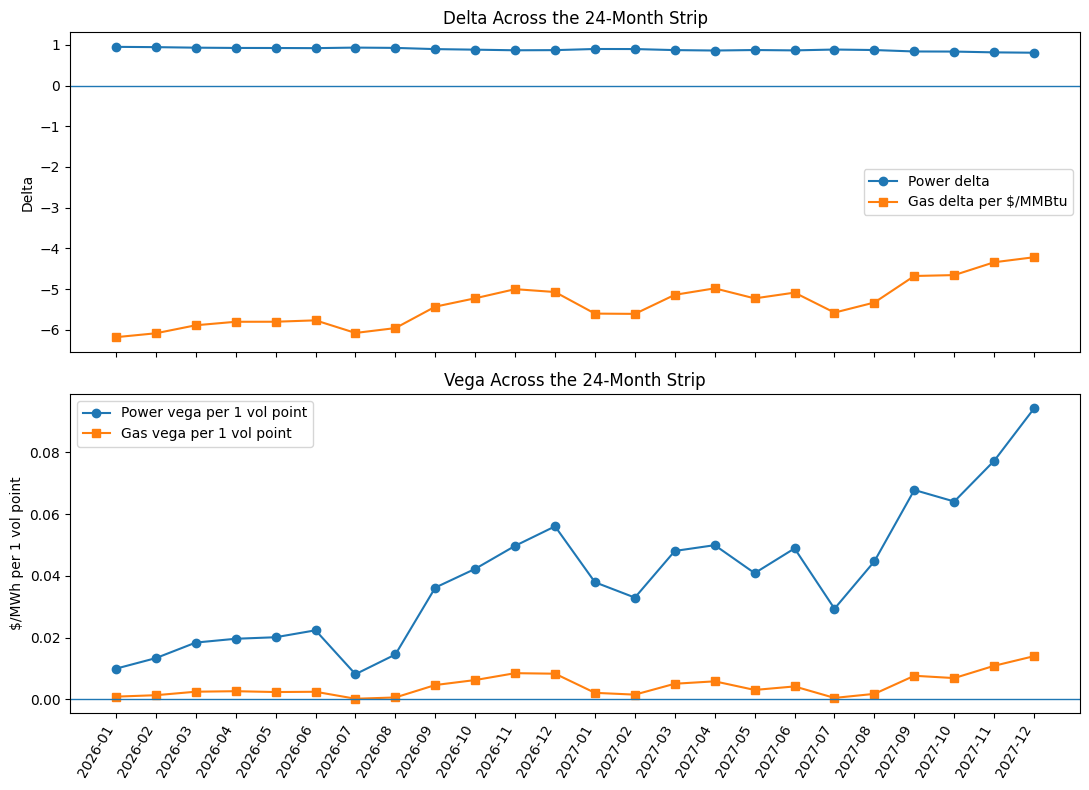

Saved: report_figures/fig4_delta_vega_across_strip.png


In [43]:
def row_price(row, F1=None, F2=None, sigma_e=None, sigma_g=None, rho=None, T=None):
    return kirk_spread_call(
        F1=row["F_elec_MWh"] if F1 is None else F1,
        F2=row["FuelCost_MWh"] if F2 is None else F2,
        sigma1=SIGMA_E if sigma_e is None else sigma_e,
        sigma2=SIGMA_G if sigma_g is None else sigma_g,
        rho=RHO if rho is None else rho,
        T=row["T_years"] if T is None else T,
        r=RF
    )

greeks = valuation.copy()

# Bump sizes
h_power = 1.0       # $/MWh
h_gas = 0.01        # $/MMBtu
h_vol = 0.01        # 1 vol point

delta_power = []
delta_gas = []
vega_power_1pct = []
vega_gas_1pct = []

for _, row in greeks.iterrows():
    base_F2 = row["FuelCost_MWh"]

    # Power delta: $/MWh option value per $1/MWh power forward
    up = row_price(row, F1=row["F_elec_MWh"] + h_power)
    dn = row_price(row, F1=row["F_elec_MWh"] - h_power)
    delta_power.append((up - dn) / (2 * h_power))

    # Gas delta: $/MWh option value per $1/MMBtu Leidy gas move
    # Fuel cost moves by HR × gas bump
    up = row_price(row, F2=base_F2 + HR * h_gas)
    dn = row_price(row, F2=base_F2 - HR * h_gas)
    delta_gas.append((up - dn) / (2 * h_gas))

    # Vega power: $/MWh change for +1 percentage point vol move
    up = row_price(row, sigma_e=SIGMA_E + h_vol)
    dn = row_price(row, sigma_e=SIGMA_E - h_vol)
    vega_power_1pct.append((up - dn) / 2)

    # Vega gas: $/MWh change for +1 percentage point vol move
    up = row_price(row, sigma_g=SIGMA_G + h_vol)
    dn = row_price(row, sigma_g=SIGMA_G - h_vol)
    vega_gas_1pct.append((up - dn) / 2)

greeks["Delta_power"] = delta_power
greeks["Delta_gas_per_MMBtu"] = delta_gas
greeks["Vega_power_1pct"] = vega_power_1pct
greeks["Vega_gas_1pct"] = vega_gas_1pct

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(x, greeks["Delta_power"], marker="o", label="Power delta")
axes[0].plot(x, greeks["Delta_gas_per_MMBtu"], marker="s", label="Gas delta per $/MMBtu")
axes[0].axhline(0, linewidth=1)
axes[0].set_ylabel("Delta")
axes[0].set_title("Delta Across the 24-Month Strip")
axes[0].legend()

axes[1].plot(x, greeks["Vega_power_1pct"], marker="o", label="Power vega per 1 vol point")
axes[1].plot(x, greeks["Vega_gas_1pct"], marker="s", label="Gas vega per 1 vol point")
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("$/MWh per 1 vol point")
axes[1].set_title("Vega Across the 24-Month Strip")
axes[1].legend()

axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=60, ha="right")

save_fig("fig4_delta_vega_across_strip.png")

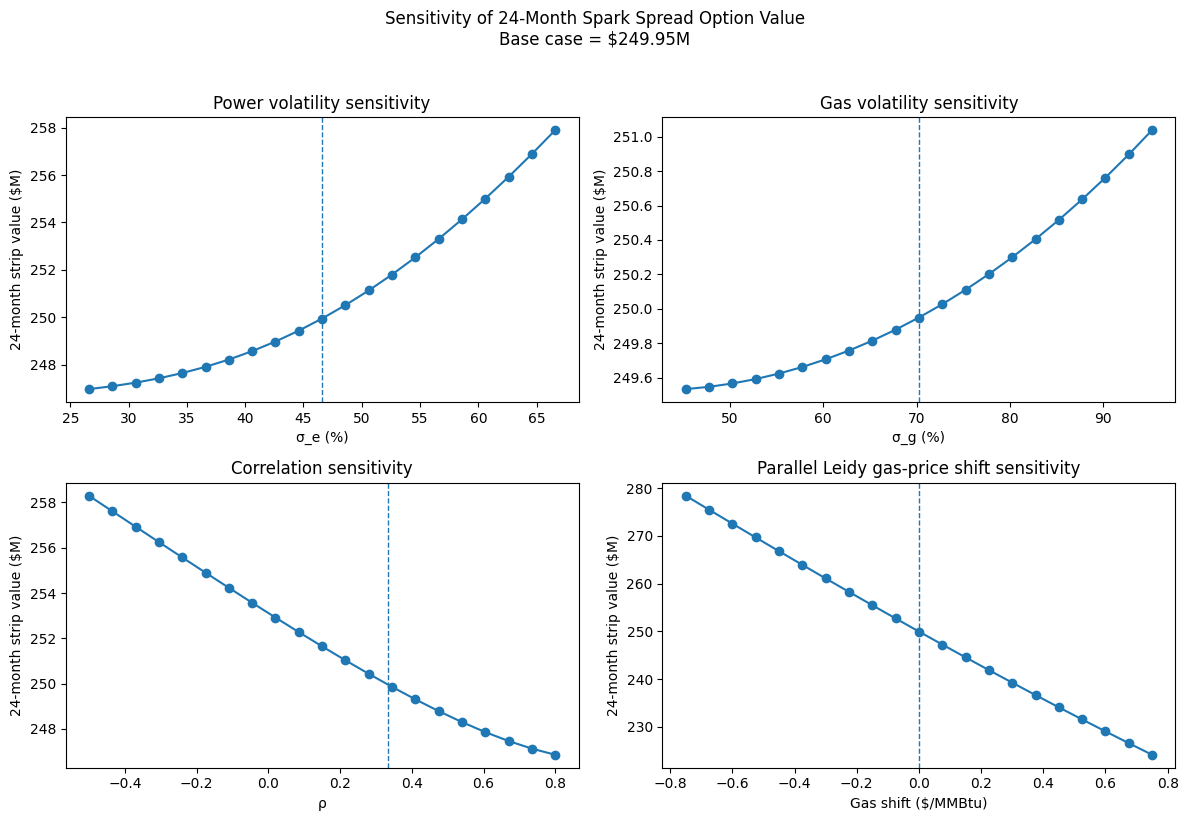

Saved: report_figures/fig5_sensitivity_analysis.png


In [45]:
base_total = total_strip_value()

sigma_e_grid = np.linspace(max(0.05, SIGMA_E - 0.20), SIGMA_E + 0.20, 21)
sigma_g_grid = np.linspace(max(0.05, SIGMA_G - 0.25), SIGMA_G + 0.25, 21)
rho_grid = np.linspace(-0.50, 0.80, 21)
gas_shift_grid = np.linspace(-0.75, 0.75, 21)

sens_power_vol = [total_strip_value(sigma_e=s) for s in sigma_e_grid]
sens_gas_vol = [total_strip_value(sigma_g=s) for s in sigma_g_grid]
sens_rho = [total_strip_value(rho=r) for r in rho_grid]
sens_gas_shift = [total_strip_value(gas_shift=g) for g in gas_shift_grid]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sigma_e_grid * 100, sens_power_vol, marker="o")
axes[0, 0].axvline(SIGMA_E * 100, linestyle="--", linewidth=1)
axes[0, 0].set_title("Power volatility sensitivity")
axes[0, 0].set_xlabel("σ_e (%)")
axes[0, 0].set_ylabel("24-month strip value ($M)")

axes[0, 1].plot(sigma_g_grid * 100, sens_gas_vol, marker="o")
axes[0, 1].axvline(SIGMA_G * 100, linestyle="--", linewidth=1)
axes[0, 1].set_title("Gas volatility sensitivity")
axes[0, 1].set_xlabel("σ_g (%)")
axes[0, 1].set_ylabel("24-month strip value ($M)")

axes[1, 0].plot(rho_grid, sens_rho, marker="o")
axes[1, 0].axvline(RHO, linestyle="--", linewidth=1)
axes[1, 0].set_title("Correlation sensitivity")
axes[1, 0].set_xlabel("ρ")
axes[1, 0].set_ylabel("24-month strip value ($M)")

axes[1, 1].plot(gas_shift_grid, sens_gas_shift, marker="o")
axes[1, 1].axvline(0, linestyle="--", linewidth=1)
axes[1, 1].set_title("Parallel Leidy gas-price shift sensitivity")
axes[1, 1].set_xlabel("Gas shift ($/MMBtu)")
axes[1, 1].set_ylabel("24-month strip value ($M)")

fig.suptitle(f"Sensitivity of 24-Month Spark Spread Option Value\nBase case = ${base_total:.2f}M", y=1.02)

save_fig("fig5_sensitivity_analysis.png")

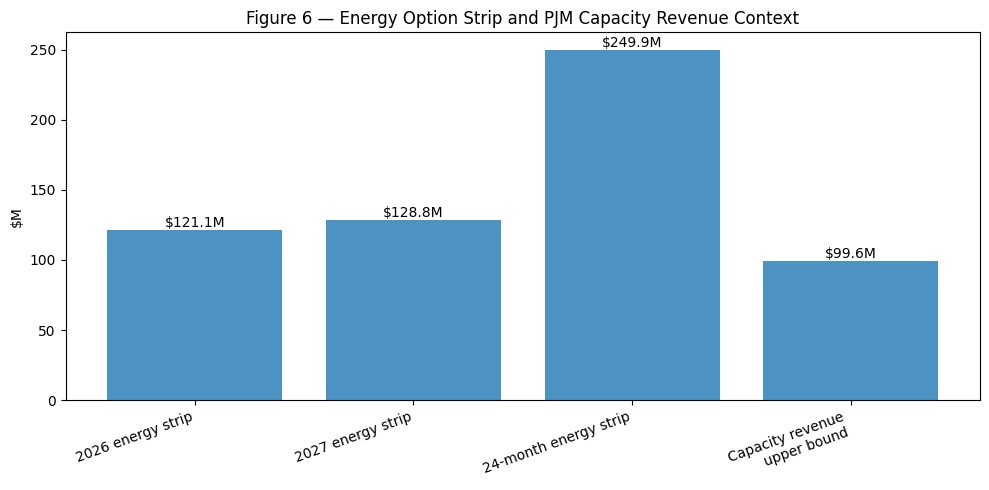

Saved: report_figures/fig6_valuation_bridge_energy_capacity.png


In [46]:
y2026 = valuation.loc[valuation["month"].str.startswith("2026"), "EnergyValue_M"].sum()
y2027 = valuation.loc[valuation["month"].str.startswith("2027"), "EnergyValue_M"].sum()
strip_total = valuation["EnergyValue_M"].sum()
cap_revenue_M = 329.17 * 365 * CAP_MW / 1e6

labels = [
    "2026 energy strip",
    "2027 energy strip",
    "24-month energy strip",
    "Capacity revenue\nupper bound"
]

values = [
    y2026,
    y2027,
    strip_total,
    cap_revenue_M
]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, alpha=0.8)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:.1f}M",
        ha="center",
        va="bottom"
    )

plt.ylabel("$M")
plt.title("Figure 6 — Energy Option Strip and PJM Capacity Revenue Context")
plt.xticks(rotation=20, ha="right")

save_fig("fig6_valuation_bridge_energy_capacity.png")